In [ ]:
S# Install PyRadiomics di Google Colab
!pip install -q SimpleITK==2.3.0 nibabel
!git clone https://github.com/AIM-Harvard/pyradiomics.git
%cd pyradiomics
!pip install .
%cd /content

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for SimpleITK (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for SimpleITK
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (SimpleITK)
Cloning into 'pyradiomics'...
remote: Enumerating objects: 7320, done.
remote: Counting objects: 100% (1756/1756), done.
remote: Compressing objects: 100% (338/338), done.
remote: Total 7320 (delta 1527), reused 1418 (delta 1418), pack-reused 5564 (from 2)
Receiving objects: 100% (7320/7320), 57.89 MiB | 40.94 MiB/s, done.
Resolving deltas: 100% (4914/4914), done.
/content/pyradiomics
P

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import SimpleITK as sitk
from radiomics import featureextractor
from tqdm import tqdm
import gc

base_dir = "/content/drive/MyDrive/kits19"

# ==========================================================
# OUTPUT CSV (SIMPLE NAME)
# ==========================================================
output_csv = os.path.join(
    base_dir,
    "radiomics_highorder.csv"
)

# Hapus file lama jika ada
if os.path.exists(output_csv):
    os.remove(output_csv)

# ==========================================================
# DAFTAR CASE TERPILIH
# ==========================================================
selected_cases = [
    "case_00001","case_00002","case_00021","case_00039","case_00044",
    "case_00050","case_00064","case_00068","case_00094","case_00099",
    "case_00103","case_00108","case_00124","case_00130","case_00146",
    "case_00158","case_00160","case_00162","case_00170","case_00209",

    "case_00003","case_00009","case_00010","case_00013","case_00024",
    "case_00025","case_00040","case_00062","case_00073","case_00080",
    "case_00089","case_00102","case_00135","case_00139","case_00153",
    "case_00157","case_00159","case_00181","case_00187",

    "case_00019","case_00020","case_00077","case_00082","case_00104",
    "case_00116","case_00155","case_00156","case_00188","case_00202"
]

print("Total case terpilih:", len(selected_cases))

# ==========================================================
# RESAMPLING FUNCTION
# ==========================================================
def resample_nifti(image_path, is_label=False, new_spacing=(2,2,2)):
    img = sitk.ReadImage(image_path)

    original_spacing = img.GetSpacing()
    original_size = img.GetSize()

    new_size = [
        int(round(original_size[i] * (original_spacing[i] / new_spacing[i])))
        for i in range(3)
    ]

    interpolator = sitk.sitkNearestNeighbor if is_label else sitk.sitkBSpline

    resampled_img = sitk.Resample(
        img,
        new_size,
        sitk.Transform(),
        interpolator,
        img.GetOrigin(),
        new_spacing,
        img.GetDirection(),
        0,
        img.GetPixelID()
    )

    return resampled_img

# ==========================================================
# PYRADIOMICS SETUP
# ==========================================================
extractor = featureextractor.RadiomicsFeatureExtractor()

extractor.disableAllImageTypes()

# =========================
# AKTIFKAN FULL HIGH-ORDER
# =========================
extractor.enableImageTypeByName("Original")

extractor.enableImageTypeByName("LoG", customArgs={"sigma": [1.0, 2.0]})

extractor.enableImageTypeByName("Wavelet", customArgs={"wavelet": "coif1"})

extractor.enableImageTypeByName("Square")
extractor.enableImageTypeByName("SquareRoot")
extractor.enableImageTypeByName("Logarithm")
extractor.enableImageTypeByName("Exponential")
extractor.enableImageTypeByName("Gradient")

# =========================
# SETTINGS
# =========================
extractor.settings.update({
    "binWidth": 25,
    "normalize": True,
    "normalizeScale": 100,
    "resampledPixelSpacing": None,
    "interpolator": sitk.sitkBSpline
})

# =========================
# BATASI FEATURE CLASS
# =========================
extractor.disableAllFeatures()
extractor.enableFeatureClassByName("firstorder")
extractor.enableFeatureClassByName("glcm")
extractor.enableFeatureClassByName("glrlm")
extractor.enableFeatureClassByName("glszm")

print("Image types aktif:", extractor.enabledImagetypes)

# ==========================================================
# LOOP EKSTRAKSI
# ==========================================================
for idx, case_id in enumerate(tqdm(selected_cases)):

    case_path = os.path.join(base_dir, case_id)
    image_path = os.path.join(case_path, "imaging.nii.gz")
    mask_path = os.path.join(case_path, "segmentation.nii.gz")

    if not (os.path.exists(image_path) and os.path.exists(mask_path)):
        print(f"Data tidak lengkap: {case_id}")
        continue

    try:
        resampled_img = resample_nifti(image_path, is_label=False)
        resampled_mask = resample_nifti(mask_path, is_label=True)

        features = extractor.execute(resampled_img, resampled_mask)

        row = {"case_id": case_id}

        for k, v in features.items():
            if "diagnostics" not in k:

                # Batasi wavelet hanya LLL dan LHL
                if "wavelet" in k:
                    if not ("LLL" in k or "LHL" in k):
                        continue

                row[k] = v

        df_row = pd.DataFrame([row])

        if idx == 0:
            df_row.to_csv(output_csv, index=False)
        else:
            df_row.to_csv(output_csv, mode='a', header=False, index=False)

        del resampled_img
        del resampled_mask
        del features
        del df_row
        gc.collect()

    except Exception as e:
        print(f"ERROR processing {case_id}: {e}")

print("Ekstraksi selesai dan disimpan:", output_csv)

INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}


Total case terpilih: 49
Image types aktif: {'Original': {}, 'LoG': {'sigma': [1.0, 2.0]}, 'Wavelet': {'wavelet': 'coif1'}, 'Square': {}, 'SquareRoot': {}, 'Logarithm': {}, 'Exponential': {}, 'Gradient': {}}


Streaming output truncated to the last 5000 lines.
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Calculating features for exponential image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Calculating features for gradient image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextrac

Ekstraksi selesai dan disimpan: /content/drive/MyDrive/kits19/radiomics_highorder.csv


In [ ]:
import pandas as pd

# =========================
# LOAD CSV HIGHORDER
# =========================
df = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_highorder.csv")

print("\nJumlah pasien:", df.shape[0])
print("Total kolom (termasuk case_id):", df.shape[1])

# =========================
# BUANG NON-FEATURE
# =========================
non_feature_cols = ["case_id"]
feature_cols = [c for c in df.columns if c not in non_feature_cols]

print("\nTotal fitur yang diekstraksi:", len(feature_cols))

# =========================
# STRUKTUR PENYIMPANAN
# =========================
structure = {
    "Original": {},
    "LoG_sigma_1.0": {},
    "LoG_sigma_2.0": {},
    "Square": {},
    "SquareRoot": {},
    "Logarithm": {},
    "Exponential": {},
    "Gradient": {},
    "Wavelet_LLL": {},
    "Wavelet_LHL": {}
}

# =========================
# FUNGSI TAMBAH FITUR
# =========================
def add_feature(group, feature_class, feature_name):
    if feature_class not in structure[group]:
        structure[group][feature_class] = []
    structure[group][feature_class].append(feature_name)

# =========================
# IDENTIFIKASI FITUR
# =========================
for col in feature_cols:

    # ORIGINAL
    if col.startswith("original_"):
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm", "shape"]:
            if f"original_{fc}_" in col:
                add_feature("Original", fc, col)

    # LoG 1.0
    elif col.startswith("log-sigma-1-0-mm-3D_"):
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            if f"log-sigma-1-0-mm-3D_{fc}_" in col:
                add_feature("LoG_sigma_1.0", fc, col)

    # LoG 2.0
    elif col.startswith("log-sigma-2-0-mm-3D_"):
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            if f"log-sigma-2-0-mm-3D_{fc}_" in col:
                add_feature("LoG_sigma_2.0", fc, col)

    # Square
    elif col.startswith("square_"):
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            if f"square_{fc}_" in col:
                add_feature("Square", fc, col)

    # SquareRoot
    elif col.startswith("squareroot_"):
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            if f"squareroot_{fc}_" in col:
                add_feature("SquareRoot", fc, col)

    # Logarithm
    elif col.startswith("logarithm_"):
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            if f"logarithm_{fc}_" in col:
                add_feature("Logarithm", fc, col)

    # Exponential
    elif col.startswith("exponential_"):
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            if f"exponential_{fc}_" in col:
                add_feature("Exponential", fc, col)

    # Gradient
    elif col.startswith("gradient_"):
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            if f"gradient_{fc}_" in col:
                add_feature("Gradient", fc, col)

    # Wavelet LLL
    elif "wavelet-LLL_" in col:
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            if f"wavelet-LLL_{fc}_" in col:
                add_feature("Wavelet_LLL", fc, col)

    # Wavelet LHL
    elif "wavelet-LHL_" in col:
        for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            if f"wavelet-LHL_{fc}_" in col:
                add_feature("Wavelet_LHL", fc, col)

# =========================
# OUTPUT RINGKASAN
# =========================
print("\n\n===== RINGKASAN FITUR =====")

grand_total = 0

for img_type, classes in structure.items():
    subtotal = sum(len(v) for v in classes.values())
    grand_total += subtotal

    print(f"\n{'='*50}")
    print(f"{img_type}  (Total: {subtotal})")
    print(f"{'='*50}")

    for fc, features in classes.items():
        print(f"  {fc:<10}: {len(features)}")

print("\n=================================")
print("TOTAL SELURUH FITUR:", grand_total)


Jumlah pasien: 49
Total kolom (termasuk case_id): 741

Total fitur yang diekstraksi: 740


===== RINGKASAN FITUR =====

Original  (Total: 74)
  firstorder: 18
  glcm      : 24
  glrlm     : 16
  glszm     : 16

LoG_sigma_1.0  (Total: 74)
  firstorder: 18
  glcm      : 24
  glrlm     : 16
  glszm     : 16

LoG_sigma_2.0  (Total: 74)
  firstorder: 18
  glcm      : 24
  glrlm     : 16
  glszm     : 16

Square  (Total: 74)
  firstorder: 18
  glcm      : 24
  glrlm     : 16
  glszm     : 16

SquareRoot  (Total: 74)
  firstorder: 18
  glcm      : 24
  glrlm     : 16
  glszm     : 16

Logarithm  (Total: 74)
  firstorder: 18
  glcm      : 24
  glrlm     : 16
  glszm     : 16

Exponential  (Total: 74)
  firstorder: 18
  glcm      : 24
  glrlm     : 16
  glszm     : 16

Gradient  (Total: 74)
  firstorder: 18
  glcm      : 24
  glrlm     : 16
  glszm     : 16

Wavelet_LLL  (Total: 74)
  firstorder: 18
  glcm      : 24
  glrlm     : 16
  glszm     : 16

Wavelet_LHL  (Total: 74)
  firstorder: 18
 

In [ ]:
import pandas as pd

# =========================
# LOAD CSV (FILE KAMU)
# =========================
df = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_highorder.csv")

# =========================
# BUANG NON-FEATURE
# =========================
non_feature_cols = ["case_id"]
feature_cols = [c for c in df.columns if c not in non_feature_cols]

print(f"\nJumlah pasien: {df.shape[0]}")
print(f"Total kolom (termasuk case_id): {df.shape[1]}")
print(f"Total kolom fitur: {len(feature_cols)}\n")

# =========================
# STRUKTUR IMAGE TYPE
# =========================
structure = {
    "Original": {},
    "LoG_sigma_1.0": {},
    "LoG_sigma_2.0": {},
    "Square": {},
    "SquareRoot": {},
    "Logarithm": {},
    "Exponential": {},
    "Gradient": {},
    "Wavelet_LLL": {},
    "Wavelet_LHL": {}
}

# =========================
# FUNGSI TAMBAH FITUR
# =========================
def add_feature(group, feature_class, feature_name):
    if feature_class not in structure[group]:
        structure[group][feature_class] = []
    structure[group][feature_class].append(feature_name)

# =========================
# IDENTIFIKASI OTOMATIS
# =========================
for col in feature_cols:

    # ORIGINAL
    if col.startswith("original_"):
        fc = col.split("_")[1]
        add_feature("Original", fc, col)

    # LoG 1.0
    elif col.startswith("log-sigma-1-0-mm-3D_"):
        fc = col.replace("log-sigma-1-0-mm-3D_", "").split("_")[0]
        add_feature("LoG_sigma_1.0", fc, col)

    # LoG 2.0
    elif col.startswith("log-sigma-2-0-mm-3D_"):
        fc = col.replace("log-sigma-2-0-mm-3D_", "").split("_")[0]
        add_feature("LoG_sigma_2.0", fc, col)

    # Square
    elif col.startswith("square_"):
        fc = col.replace("square_", "").split("_")[0]
        add_feature("Square", fc, col)

    # SquareRoot
    elif col.startswith("squareroot_"):
        fc = col.replace("squareroot_", "").split("_")[0]
        add_feature("SquareRoot", fc, col)

    # Logarithm
    elif col.startswith("logarithm_"):
        fc = col.replace("logarithm_", "").split("_")[0]
        add_feature("Logarithm", fc, col)

    # Exponential
    elif col.startswith("exponential_"):
        fc = col.replace("exponential_", "").split("_")[0]
        add_feature("Exponential", fc, col)

    # Gradient
    elif col.startswith("gradient_"):
        fc = col.replace("gradient_", "").split("_")[0]
        add_feature("Gradient", fc, col)

    # Wavelet LLL
    elif col.startswith("wavelet-LLL_"):
        fc = col.replace("wavelet-LLL_", "").split("_")[0]
        add_feature("Wavelet_LLL", fc, col)

    # Wavelet LHL
    elif col.startswith("wavelet-LHL_"):
        fc = col.replace("wavelet-LHL_", "").split("_")[0]
        add_feature("Wavelet_LHL", fc, col)

# =========================
# OUTPUT DETAIL
# =========================
print("===== RINGKASAN & DAFTAR FITUR =====")

grand_total = 0

for img_type, classes in structure.items():

    subtotal = sum(len(v) for v in classes.values())
    grand_total += subtotal

    print(f"\n{'='*50}")
    print(f"{img_type}  (Total: {subtotal})")
    print(f"{'='*50}")

    for fc, features in classes.items():
        print(f"\n  {fc.upper()}  -> {len(features)} fitur")
        for f in sorted(features):
            print(f"     - {f}")

print("\n=================================")
print(f"TOTAL SELURUH FITUR: {grand_total}")


Jumlah pasien: 49
Total kolom (termasuk case_id): 741
Total kolom fitur: 740

===== RINGKASAN & DAFTAR FITUR =====

Original  (Total: 74)

  FIRSTORDER  -> 18 fitur
     - original_firstorder_10Percentile
     - original_firstorder_90Percentile
     - original_firstorder_Energy
     - original_firstorder_Entropy
     - original_firstorder_InterquartileRange
     - original_firstorder_Kurtosis
     - original_firstorder_Maximum
     - original_firstorder_Mean
     - original_firstorder_MeanAbsoluteDeviation
     - original_firstorder_Median
     - original_firstorder_Minimum
     - original_firstorder_Range
     - original_firstorder_RobustMeanAbsoluteDeviation
     - original_firstorder_RootMeanSquared
     - original_firstorder_Skewness
     - original_firstorder_TotalEnergy
     - original_firstorder_Uniformity
     - original_firstorder_Variance

  GLCM  -> 24 fitur
     - original_glcm_Autocorrelation
     - original_glcm_ClusterProminence
     - original_glcm_ClusterShade
     - 

FEATURE SELECTION

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, VarianceThreshold
from sklearn.svm import LinearSVC

# =====================================================
# LOAD FEATURE DATA (FULL HIGH ORDER - 740 FITUR)
# =====================================================
df_features = pd.read_csv(
    "/content/drive/MyDrive/kits19/radiomics_highorder.csv"
)

df_features.columns = df_features.columns.str.strip()

print("Jumlah pasien:", df_features.shape[0])
print("Total kolom (termasuk case_id):", df_features.shape[1])

# =====================================================
# BUANG KOLOM DIAGNOSTICS JIKA ADA
# =====================================================
df_features = df_features.loc[:, ~df_features.columns.str.startswith("diagnostics")]

# =====================================================
# LOAD LABEL DAN MERGE
# =====================================================
df_label = pd.read_csv(
    "/content/drive/MyDrive/kits19/radiomics_label.csv"
)

df_label.columns = df_label.columns.str.strip()

TARGET_SUBTYPES = ["papillary", "chromophobe", "oncocytoma"]
df_label = df_label[df_label["subtype"].isin(TARGET_SUBTYPES)]

df = df_features.merge(
    df_label[["case_id", "subtype"]],
    on="case_id",
    how="inner"
)

print("Jumlah pasien setelah merge:", df.shape[0])

# =====================================================
# LABEL MAPPING
# =====================================================
label_mapping = {
    "papillary": 1,
    "chromophobe": 0,
    "oncocytoma": 0
}

df["label"] = df["subtype"].map(label_mapping)

if df["label"].isnull().any():
    raise ValueError("Ada subtype yang belum termapping!")

y = df["label"].values

print("\nDistribusi kelas:")
print(df["subtype"].value_counts())

# =====================================================
# PERSIAPAN FITUR
# =====================================================
case_ids = df["case_id"]

X = df.drop(columns=["case_id", "subtype", "label"]).select_dtypes(include=[np.number])

print("\nTotal fitur awal:", X.shape[1])

# =====================================================
# 1️⃣ VARIANCE FILTER
# =====================================================
var_filter = VarianceThreshold(threshold=0.01)
X_var = var_filter.fit_transform(X)

X_var = pd.DataFrame(
    X_var,
    columns=X.columns[var_filter.get_support()]
)

print("Total fitur setelah variance filter:", X_var.shape[1])

# =====================================================
# 2️⃣ CORRELATION FILTER (0.90)
# =====================================================
corr_threshold = 0.90

corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
X_corr = X_var.drop(columns=to_drop)

print(f"Total fitur setelah correlation filter (threshold={corr_threshold}):", X_corr.shape[1])

# =====================================================
# 3️⃣ SCALING
# =====================================================
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_corr),
    columns=X_corr.columns
)

# =====================================================
# SUMMARY FUNCTION (LEBIH ROBUST UNTUK PREFIX KOMPLEKS)
# =====================================================
def summarize_features(feature_list, title):

    series = pd.Series(feature_list)

    # Ambil image type (prefix sebelum feature class)
    image_type = series.str.extract(r"^(.*?)_(firstorder|glcm|glrlm|glszm)")[0]
    feature_class = series.str.extract(r"_(firstorder|glcm|glrlm|glszm)_")[0]

    print("\n==============================")
    print(f"=== {title} ===")
    print("Total fitur:", len(series))

    print("\nDistribusi IMAGE TYPE:")
    print(image_type.value_counts())

    print("\nDistribusi FEATURE CLASS:")
    print(feature_class.value_counts())

# =====================================================
# 4️⃣ ANOVA (k = 20)
# =====================================================
anova = SelectKBest(f_classif, k=20)
anova.fit(X_scaled, y)

anova_features = X_scaled.columns[anova.get_support()].tolist()
summarize_features(anova_features, "ANOVA (k=20)")

# =====================================================
# 5️⃣ RFE + Linear SVM (20 fitur)
# =====================================================
svm = LinearSVC(
    dual=False,
    max_iter=10000,
    random_state=42
)

rfe = RFE(estimator=svm, n_features_to_select=20)
rfe.fit(X_scaled, y)

rfe_features = X_scaled.columns[rfe.support_].tolist()
summarize_features(rfe_features, "RFE + Linear SVM (20 fitur)")

# =====================================================
# 6️⃣ MUTUAL INFORMATION (Top 20)
# =====================================================
mi_scores = mutual_info_classif(
    X_scaled,
    y,
    random_state=42
)

mi_features = (
    pd.Series(mi_scores, index=X_scaled.columns)
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

summarize_features(mi_features, "Mutual Information (Top 20)")

# =====================================================
# 7️⃣ SAVE OUTPUT (TIDAK OVERWRITE)
# =====================================================
def save_fs_output(features, method_name):

    df_out = pd.concat([case_ids, X_corr[features]], axis=1)

    output_path = f"/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDER_{method_name}.csv"
    df_out.to_csv(output_path, index=False)

    print(f"\n✅ Output {method_name} disimpan di:")
    print(output_path)

save_fs_output(anova_features, "ANOVA")
save_fs_output(rfe_features, "RFE_LSVM")
save_fs_output(mi_features, "MI")

Jumlah pasien: 49
Total kolom (termasuk case_id): 741
Jumlah pasien setelah merge: 49

Distribusi kelas:
subtype
papillary      20
chromophobe    19
oncocytoma     10
Name: count, dtype: int64

Total fitur awal: 740
Total fitur setelah variance filter: 528
Total fitur setelah correlation filter (threshold=0.9): 155

=== ANOVA (k=20) ===
Total fitur: 20

Distribusi IMAGE TYPE:
0
original               4
exponential            4
squareroot             4
square                 3
wavelet-LHL            2
logarithm              2
log-sigma-2-0-mm-3D    1
Name: count, dtype: int64

Distribusi FEATURE CLASS:
0
glrlm         9
glszm         6
firstorder    3
glcm          2
Name: count, dtype: int64

=== RFE + Linear SVM (20 fitur) ===
Total fitur: 20

Distribusi IMAGE TYPE:
0
original       4
exponential    4
square         3
wavelet-LHL    3
wavelet-LLL    2
squareroot     2
logarithm      1
gradient       1
Name: count, dtype: int64

Distribusi FEATURE CLASS:
0
glszm         9
glrlm        

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, VarianceThreshold
from sklearn.svm import LinearSVC

# =====================================================
# LOAD FEATURE DATA (FULL HIGH ORDER - 740 FITUR)
# =====================================================
df_features = pd.read_csv(
    "/content/drive/MyDrive/kits19/radiomics_highorder.csv"
)

df_features.columns = df_features.columns.str.strip()

print("Jumlah pasien:", df_features.shape[0])
print("Total kolom (termasuk case_id):", df_features.shape[1])

# =====================================================
# BUANG KOLOM DIAGNOSTICS JIKA ADA
# =====================================================
df_features = df_features.loc[:, ~df_features.columns.str.startswith("diagnostics")]

# =====================================================
# LOAD LABEL DAN MERGE
# =====================================================
df_label = pd.read_csv(
    "/content/drive/MyDrive/kits19/radiomics_label.csv"
)

df_label.columns = df_label.columns.str.strip()

TARGET_SUBTYPES = ["papillary", "chromophobe", "oncocytoma"]
df_label = df_label[df_label["subtype"].isin(TARGET_SUBTYPES)]

df = df_features.merge(
    df_label[["case_id", "subtype"]],
    on="case_id",
    how="inner"
)

print("Jumlah pasien setelah merge:", df.shape[0])

# =====================================================
# LABEL MAPPING
# =====================================================
label_mapping = {
    "papillary": 1,
    "chromophobe": 0,
    "oncocytoma": 0
}

df["label"] = df["subtype"].map(label_mapping)

if df["label"].isnull().any():
    raise ValueError("Ada subtype yang belum termapping!")

y = df["label"].values

print("\nDistribusi kelas:")
print(df["subtype"].value_counts())

# =====================================================
# PERSIAPAN FITUR
# =====================================================
case_ids = df["case_id"]

X = df.drop(columns=["case_id", "subtype", "label"]).select_dtypes(include=[np.number])

print("\nTotal fitur awal:", X.shape[1])

# =====================================================
# 1️⃣ VARIANCE FILTER
# =====================================================
var_filter = VarianceThreshold(threshold=0.01)
X_var = var_filter.fit_transform(X)

X_var = pd.DataFrame(
    X_var,
    columns=X.columns[var_filter.get_support()]
)

print("Total fitur setelah variance filter:", X_var.shape[1])

# =====================================================
# 2️⃣ CORRELATION FILTER (0.90)
# =====================================================
corr_threshold = 0.90

corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
X_corr = X_var.drop(columns=to_drop)

print(f"Total fitur setelah correlation filter (threshold={corr_threshold}):", X_corr.shape[1])

# =====================================================
# 3️⃣ SCALING
# =====================================================
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_corr),
    columns=X_corr.columns
)

# =====================================================
# FUNCTION UNTUK EKSTRAK DETAIL FITUR
# =====================================================
def extract_feature_details(feature_list, scores=None):

    data = []

    for i, feat in enumerate(feature_list):

        # Extract image type
        image_type = None
        feature_class = None

        for cls in ["firstorder", "glcm", "glrlm", "glszm"]:
            if f"_{cls}_" in feat:
                feature_class = cls
                image_type = feat.split(f"_{cls}_")[0]
                break

        row = {
            "rank": i + 1,
            "feature_name": feat,
            "image_type": image_type,
            "feature_class": feature_class
        }

        if scores is not None:
            row["score"] = scores[feat]

        data.append(row)

    return pd.DataFrame(data)

# =====================================================
# 4️⃣ ANOVA (k = 20)
# =====================================================
anova = SelectKBest(f_classif, k=20)
anova.fit(X_scaled, y)

anova_features = X_scaled.columns[anova.get_support()].tolist()

anova_scores_dict = dict(zip(X_scaled.columns, anova.scores_))

anova_detail = extract_feature_details(
    anova_features,
    scores=anova_scores_dict
)

print("\n==============================")
print("ANOVA SELECTED FEATURES")
print(anova_detail)

# =====================================================
# 5️⃣ RFE + Linear SVM (20 fitur)
# =====================================================
svm = LinearSVC(
    dual=False,
    max_iter=10000,
    random_state=42
)

rfe = RFE(estimator=svm, n_features_to_select=20)
rfe.fit(X_scaled, y)

rfe_features = X_scaled.columns[rfe.support_].tolist()

rfe_detail = extract_feature_details(rfe_features)

print("\n==============================")
print("RFE SELECTED FEATURES")
print(rfe_detail)

# =====================================================
# 6️⃣ MUTUAL INFORMATION (Top 20)
# =====================================================
mi_scores = mutual_info_classif(
    X_scaled,
    y,
    random_state=42
)

mi_series = pd.Series(mi_scores, index=X_scaled.columns).sort_values(ascending=False)

mi_features = mi_series.head(20).index.tolist()

mi_detail = extract_feature_details(
    mi_features,
    scores=mi_series.to_dict()
)

print("\n==============================")
print("MUTUAL INFORMATION SELECTED FEATURES")
print(mi_detail)

# =====================================================
# 7️⃣ SAVE DATASET HASIL SELEKSI UNTUK MODELING
# =====================================================
def save_fs_dataset(features, method_name):

    df_out = pd.concat([case_ids, X_corr[features]], axis=1)

    output_path = f"/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDER_{method_name}.csv"
    df_out.to_csv(output_path, index=False)

    print(f"\n✅ Dataset {method_name} disimpan di:")
    print(output_path)

save_fs_dataset(anova_features, "ANOVA")
save_fs_dataset(rfe_features, "RFE_LSVM")
save_fs_dataset(mi_features, "MI")

# =====================================================
# 8️⃣ SAVE DETAIL FITUR TERPILIH
# =====================================================
anova_detail.to_csv(
    "/content/drive/MyDrive/kits19/FS_DETAIL_ANOVA.csv",
    index=False
)

rfe_detail.to_csv(
    "/content/drive/MyDrive/kits19/FS_DETAIL_RFE_LSVM.csv",
    index=False
)

mi_detail.to_csv(
    "/content/drive/MyDrive/kits19/FS_DETAIL_MI.csv",
    index=False
)

print("\n✅ Detail fitur terpilih berhasil disimpan.")

Jumlah pasien: 49
Total kolom (termasuk case_id): 741
Jumlah pasien setelah merge: 49

Distribusi kelas:
subtype
papillary      20
chromophobe    19
oncocytoma     10
Name: count, dtype: int64

Total fitur awal: 740
Total fitur setelah variance filter: 528
Total fitur setelah correlation filter (threshold=0.9): 155

ANOVA SELECTED FEATURES
    rank                                       feature_name  \
0      1                        original_firstorder_Maximum   
1      2              original_glrlm_GrayLevelNonUniformity   
2      3        original_glrlm_LongRunHighGrayLevelEmphasis   
3      4                          original_glrlm_RunEntropy   
4      5        log-sigma-2-0-mm-3D_glszm_LargeAreaEmphasis   
5      6                     wavelet-LHL_firstorder_Maximum   
6      7                      wavelet-LHL_glszm_ZoneEntropy   
7      8                         square_firstorder_Variance   
8      9                        square_glcm_ClusterTendency   
9     10         square_glrl

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, VarianceThreshold
from sklearn.svm import LinearSVC

# =====================================================
# LOAD FEATURE DATA
# =====================================================

df_features = pd.read_csv(
    "/content/drive/MyDrive/kits19/radiomics_highorder.csv"
)

df_features.columns = df_features.columns.str.strip()
df_features = df_features.loc[:, ~df_features.columns.str.startswith("diagnostics")]

print("Jumlah pasien:", df_features.shape[0])

# =====================================================
# LOAD LABEL
# =====================================================

df_label = pd.read_csv(
    "/content/drive/MyDrive/kits19/radiomics_label.csv"
)

df_label.columns = df_label.columns.str.strip()

df = df_features.merge(
    df_label[["case_id", "subtype"]],
    on="case_id",
    how="inner"
)

# Binary mapping
label_mapping = {
    "papillary": 1,
    "chromophobe": 0,
    "oncocytoma": 0
}

df["label"] = df["subtype"].map(label_mapping)

X = df.drop(columns=["case_id", "subtype", "label"]).select_dtypes(include=[np.number])
y = df["label"].values

print("Total fitur awal:", X.shape[1])

# =====================================================
# OUTER CV
# =====================================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

anova_selected_all = []
rfe_selected_all = []
mi_selected_all = []

fold_idx = 1

for train_idx, test_idx in outer_cv.split(X, y):

    print(f"\n========== OUTER FOLD {fold_idx} ==========")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # ==============================
    # Variance Filter (TRAIN ONLY)
    # ==============================
    var_filter = VarianceThreshold(threshold=0.01)
    X_train_var = var_filter.fit_transform(X_train)
    X_test_var = var_filter.transform(X_test)

    var_cols = X_train.columns[var_filter.get_support()]

    X_train_var = pd.DataFrame(X_train_var, columns=var_cols)
    X_test_var = pd.DataFrame(X_test_var, columns=var_cols)

    # ==============================
    # Correlation Filter (TRAIN ONLY)
    # ==============================
    corr_matrix = X_train_var.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

    X_train_corr = X_train_var.drop(columns=to_drop)
    X_test_corr = X_test_var.drop(columns=to_drop)

    # ==============================
    # Scaling (TRAIN ONLY)
    # ==============================
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_corr)
    X_test_scaled = scaler.transform(X_test_corr)

    X_train_scaled = pd.DataFrame(
        X_train_scaled,
        columns=X_train_corr.columns
    )

    # =====================================================
    # 1️⃣ ANOVA
    # =====================================================
    anova = SelectKBest(f_classif, k=20)
    anova.fit(X_train_scaled, y_train)

    anova_features = X_train_scaled.columns[anova.get_support()].tolist()
    anova_selected_all.extend(anova_features)

    print("ANOVA selected:", len(anova_features))

    # =====================================================
    # 2️⃣ RFE
    # =====================================================
    svm = LinearSVC(
        dual=False,
        max_iter=10000,
        random_state=42
    )

    rfe = RFE(estimator=svm, n_features_to_select=20)
    rfe.fit(X_train_scaled, y_train)

    rfe_features = X_train_scaled.columns[rfe.support_].tolist()
    rfe_selected_all.extend(rfe_features)

    print("RFE selected:", len(rfe_features))

    # =====================================================
    # 3️⃣ MI
    # =====================================================
    mi_scores = mutual_info_classif(
        X_train_scaled,
        y_train,
        random_state=42
    )

    mi_features = (
        pd.Series(mi_scores, index=X_train_scaled.columns)
        .sort_values(ascending=False)
        .head(20)
        .index
        .tolist()
    )

    mi_selected_all.extend(mi_features)

    print("MI selected:", len(mi_features))

    fold_idx += 1


# =====================================================
# FEATURE STABILITY + SAVE CSV
# =====================================================

def save_stable_features(feature_list, method_name, top_k=20):

    print("\n================================")
    print(f"{method_name} STABILITY")
    print("================================")

    freq = pd.Series(feature_list).value_counts()

    print("\nTop fitur paling stabil:")
    print(freq.head(top_k))

    # Ambil top_k fitur paling sering muncul
    stable_features = freq.head(top_k).index.tolist()

    # Buat dataframe final (pakai seluruh dataset, tapi hanya fitur stabil)
    df_final = pd.concat(
        [df[["case_id"]], X[stable_features]],
        axis=1
    )

    output_path = f"/content/drive/MyDrive/kits19/radiomics_STABLE_{method_name}.csv"
    df_final.to_csv(output_path, index=False)

    print(f"\n✅ CSV disimpan di:")
    print(output_path)

    return stable_features


# =====================================================
# SAVE 3 METHODS
# =====================================================

stable_anova = save_stable_features(anova_selected_all, "ANOVA")
stable_rfe   = save_stable_features(rfe_selected_all, "RFE")
stable_mi    = save_stable_features(mi_selected_all, "MI")

Jumlah pasien: 49
Total fitur awal: 740

========== OUTER FOLD 1 ==========
ANOVA selected: 20
RFE selected: 20
MI selected: 20

========== OUTER FOLD 2 ==========
ANOVA selected: 20
RFE selected: 20
MI selected: 20

========== OUTER FOLD 3 ==========
ANOVA selected: 20
RFE selected: 20
MI selected: 20

========== OUTER FOLD 4 ==========
ANOVA selected: 20
RFE selected: 20
MI selected: 20

========== OUTER FOLD 5 ==========
ANOVA selected: 20
RFE selected: 20
MI selected: 20

ANOVA STABILITY

Top fitur paling stabil:
original_glrlm_RunEntropy                                     5
square_glrlm_ShortRunHighGrayLevelEmphasis                    5
squareroot_glszm_GrayLevelVariance                            5
squareroot_glrlm_RunEntropy                                   4
exponential_glcm_Correlation                                  4
squareroot_glrlm_GrayLevelNonUniformity                       4
original_glrlm_LongRunHighGrayLevelEmphasis                   3
exponential_glszm_LargeAreaEm

XGBOOST

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)
from xgboost import XGBClassifier

# ============================================================
# LOAD LABEL (PAPILLARY = 1)
# ============================================================

df_label = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_label.csv")
df_label.columns = df_label.columns.str.strip()

# Papillary = 1
df_label["label"] = df_label["subtype"].apply(
    lambda x: 1 if x == "papillary" else 0
)

print("\nDistribusi Kelas:")
print(df_label["label"].value_counts())

# ============================================================
# CV STRATEGY
# ============================================================

cv_tuning = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

cv_eval = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# PARAM GRID (STABIL UNTUK DATASET KECIL)
# ============================================================

param_grid = {
    "clf__n_estimators": [50, 80, 120],
    "clf__max_depth": [2, 3],
    "clf__learning_rate": [0.03, 0.05, 0.08],
    "clf__subsample": [0.7, 0.8],
    "clf__colsample_bytree": [0.6, 0.8],
    "clf__gamma": [0, 0.1],
    "clf__min_child_weight": [1, 2],
    "clf__reg_lambda": [1, 3, 5],
    "clf__reg_alpha": [0, 0.5, 1]
}

# ============================================================
# EVALUATION FUNCTION (MACRO F1)
# ============================================================

def evaluate_model(csv_path, model_name):

    print("\n==============================")
    print("MODEL:", model_name)
    print("==============================")

    df = pd.read_csv(csv_path)

    df = df.merge(
        df_label[["case_id", "label"]],
        on="case_id",
        how="inner"
    )

    X = df.drop(columns=["case_id", "label"])
    y = df["label"]

    print("Jumlah fitur:", X.shape[1])
    print("Jumlah sampel:", X.shape[0])

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            use_label_encoder=False
        ))
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=50,
        scoring="f1_macro",   # <<< DIUBAH
        n_jobs=-1,
        cv=cv_tuning,
        verbose=1,
        random_state=42
    )

    search.fit(X, y)

    print("\nBest Params:", search.best_params_)
    print("Best CV Macro-F1 (Tuning):", search.best_score_)

    # =========================
    # FINAL EVALUATION
    # =========================

    y_pred = cross_val_predict(
        search.best_estimator_,
        X,
        y,
        cv=cv_eval
    )

    y_proba = cross_val_predict(
        search.best_estimator_,
        X,
        y,
        cv=cv_eval,
        method="predict_proba"
    )[:, 1]

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1_binary = f1_score(y, y_pred)
    f1_macro = f1_score(y, y_pred, average="macro")
    cm = confusion_matrix(y, y_pred)

    auc = roc_auc_score(y, y_proba)

    print("\nFinal 5-Fold Evaluation")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 (Binary) :", round(f1_binary,4))
    print("F1 (Macro)  :", round(f1_macro,4))
    print("AUC :", round(auc,4))
    print("Confusion Matrix:\n", cm)

    return search.best_estimator_

# ============================================================
# RUN MODELS
# ============================================================

model_anova = evaluate_model(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERANOVA.csv",
    "XGBoost + ANOVA (Binary, Papillary=1)"
)

model_rfe = evaluate_model(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERRFE_LSVM.csv",
    "XGBoost + RFE (Binary, Papillary=1)"
)

model_mi = evaluate_model(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERMI.csv",
    "XGBoost + MI (Binary, Papillary=1)"
)


Distribusi Kelas:
label
0    29
1    20
Name: count, dtype: int64

MODEL: XGBoost + ANOVA (Binary, Papillary=1)
Jumlah fitur: 20
Jumlah sampel: 49
Fitting 25 folds for each of 50 candidates, totalling 1250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Best Params: {'clf__subsample': 0.7, 'clf__reg_lambda': 1, 'clf__reg_alpha': 0.5, 'clf__n_estimators': 120, 'clf__min_child_weight': 2, 'clf__max_depth': 2, 'clf__learning_rate': 0.08, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.8}
Best CV Macro-F1 (Tuning): 0.5083251193251194


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Final 5-Fold Evaluation
Accuracy : 0.5102
Precision: 0.375
Recall   : 0.3
F1 (Binary) : 0.3333
F1 (Macro)  : 0.4731
AUC : 0.4897
Confusion Matrix:
 [[19 10]
 [14  6]]

MODEL: XGBoost + RFE (Binary, Papillary=1)
Jumlah fitur: 20
Jumlah sampel: 49
Fitting 25 folds for each of 50 candidates, totalling 1250 fits


...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Params: {'clf__subsample': 0.7, 'clf__reg_lambda': 3, 'clf__reg_alpha': 0.5, 'clf__n_estimators': 120, 'clf__min_child_weight': 1, 'clf__max_depth': 2, 'clf__learning_rate': 0.03, 'clf__gamma': 0, 'clf__colsample_bytree': 0.6}
Best CV Macro-F1 (Tuning): 0.5521572871572872


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Final 5-Fold Evaluation
Accuracy : 0.6531
Precision: 0.6154
Recall   : 0.4
F1 (Binary) : 0.4848
F1 (Macro)  : 0.6117
AUC : 0.619
Confusion Matrix:
 [[24  5]
 [12  8]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:31:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


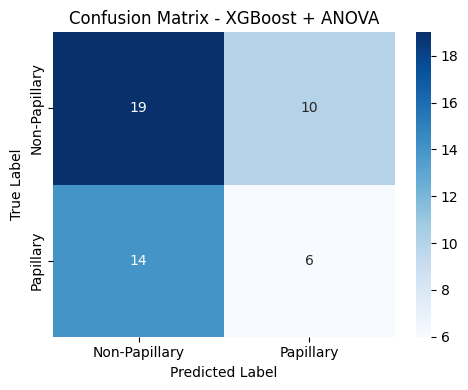

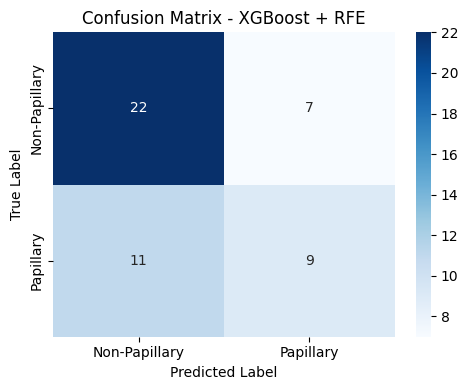

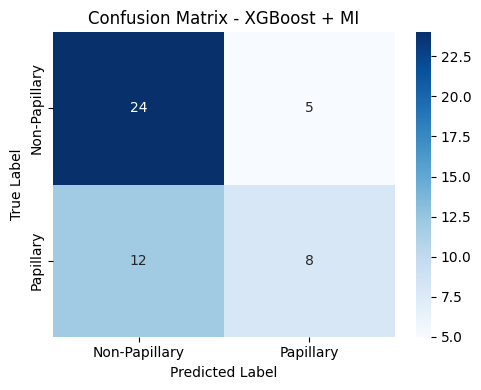

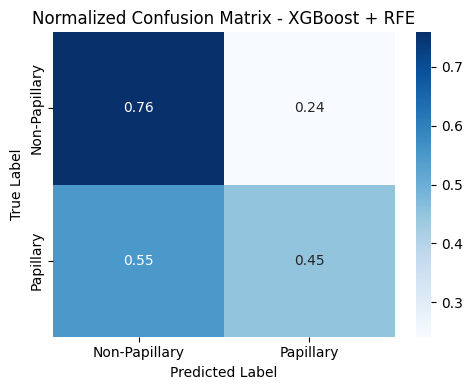

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# XGBoost + ANOVA
# =========================
cm_anova = np.array([[19, 10],
                     [14,  6]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_anova, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - XGBoost + ANOVA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# =========================
# XGBoost + RFE
# =========================
cm_rfe = np.array([[22, 7],
                   [11, 9]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_rfe, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - XGBoost + RFE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# =========================
# XGBoost + MI
# =========================
cm_mi = np.array([[24, 5],
                  [12, 8]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_mi, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - XGBoost + MI")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# =========================
# Normalized Confusion Matrix (RFE - Best Model)
# =========================
plt.figure(figsize=(5,4))
sns.heatmap(cm_rfe / cm_rfe.sum(axis=1, keepdims=True),
            annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Normalized Confusion Matrix - XGBoost + RFE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

RANDOM FOREST

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# ============================================================
# 1. LOAD LABEL (PAPILLARY = 1)
# ============================================================

df_label = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_label.csv")
df_label.columns = df_label.columns.str.strip()

# Papillary jadi kelas positif (1)
df_label["label"] = df_label["subtype"].apply(
    lambda x: 1 if x == "papillary" else 0
)

print("\nDistribusi Kelas:")
print(df_label["label"].value_counts())

# ============================================================
# 2. CROSS VALIDATION STRATEGY
# ============================================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# ============================================================
# 3. RF PARAMETER GRID (DATASET KECIL)
# ============================================================

rf_param_grid = {
    "clf__n_estimators": [50, 80, 120],
    "clf__max_depth": [2, 3, 4, None],
    "clf__min_samples_split": [2, 3, 4],
    "clf__min_samples_leaf": [1, 2, 3],
    "clf__max_features": ["sqrt", 0.5, 0.7],
    "clf__bootstrap": [True],
    "clf__criterion": ["gini"],
}

# ============================================================
# 4. NESTED CV FUNCTION (MACRO F1)
# ============================================================

def evaluate_rf_binary(csv_path, model_name):

    print("\n====================================")
    print("MODEL:", model_name)
    print("====================================")

    df = pd.read_csv(csv_path)

    df = df.merge(
        df_label[["case_id", "label"]],
        on="case_id",
        how="inner"
    )

    X = df.drop(columns=["case_id", "label"])
    y = df["label"]

    print("Jumlah fitur :", X.shape[1])
    print("Jumlah sampel:", X.shape[0])

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    fold_idx = 1

    for train_idx, test_idx in outer_cv.split(X, y):

        print(f"\n--- Outer Fold {fold_idx} ---")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ])

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=rf_param_grid,
            n_iter=40,
            scoring="f1_macro",   # <<< DIUBAH
            n_jobs=-1,
            cv=inner_cv,
            random_state=42,
            verbose=0
        )

        search.fit(X_train, y_train)

        best_model = search.best_estimator_

        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(y_proba)

        print("Best Inner CV Macro-F1:", search.best_score_)

        fold_idx += 1

    y_proba_all = np.array(y_proba_all)

    # ============================================================
    # FINAL METRICS
    # ============================================================

    acc = accuracy_score(y_true_all, y_pred_all)
    prec = precision_score(y_true_all, y_pred_all)
    rec = recall_score(y_true_all, y_pred_all)
    f1_binary = f1_score(y_true_all, y_pred_all)
    f1_macro = f1_score(y_true_all, y_pred_all, average="macro")
    cm = confusion_matrix(y_true_all, y_pred_all)

    auc = roc_auc_score(y_true_all, y_proba_all)

    print("\n===== FINAL NESTED CV RESULT =====")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 (Binary) :", round(f1_binary,4))
    print("F1 (Macro)  :", round(f1_macro,4))
    print("AUC :", round(auc,4))
    print("Confusion Matrix:\n", cm)

    return acc, prec, rec, f1_binary, f1_macro, auc, cm


# ============================================================
# 5. RUN
# ============================================================

rf_anova = evaluate_rf_binary(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERANOVA.csv",
    "Random Forest + ANOVA (Binary, Papillary=1)"
)

rf_rfe = evaluate_rf_binary(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERRFE_LSVM.csv",
    "Random Forest + RFE (Binary, Papillary=1)"
)

rf_mi = evaluate_rf_binary(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERMI.csv",
    "Random Forest + MI (Binary, Papillary=1)"
)


Distribusi Kelas:
label
0    29
1    20
Name: count, dtype: int64

MODEL: Random Forest + ANOVA (Binary, Papillary=1)
Jumlah fitur : 20
Jumlah sampel: 49

--- Outer Fold 1 ---
Best Inner CV Macro-F1: 0.4519230769230769

--- Outer Fold 2 ---
Best Inner CV Macro-F1: 0.6482822732822733

--- Outer Fold 3 ---
Best Inner CV Macro-F1: 0.5940934065934066

--- Outer Fold 4 ---
Best Inner CV Macro-F1: 0.7246711621711621

--- Outer Fold 5 ---
Best Inner CV Macro-F1: 0.6749084249084248

===== FINAL NESTED CV RESULT =====
Accuracy : 0.5918
Precision: 0.5
Recall   : 0.25
F1 (Binary) : 0.3333
F1 (Macro)  : 0.5196
AUC : 0.5276
Confusion Matrix:
 [[24  5]
 [15  5]]

MODEL: Random Forest + RFE (Binary, Papillary=1)
Jumlah fitur : 20
Jumlah sampel: 49

--- Outer Fold 1 ---
Best Inner CV Macro-F1: 0.6278159340659341

--- Outer Fold 2 ---
Best Inner CV Macro-F1: 0.6133033633033633

--- Outer Fold 3 ---
Best Inner CV Macro-F1: 0.5977564102564102

--- Outer Fold 4 ---
Best Inner CV Macro-F1: 0.6513472638472

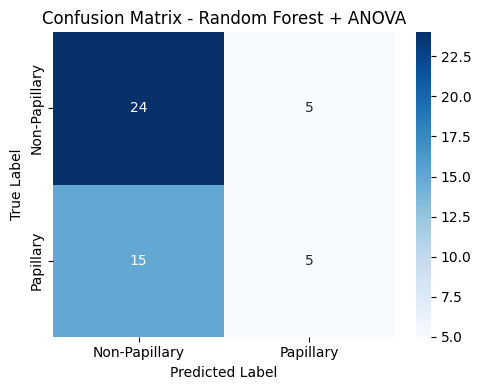

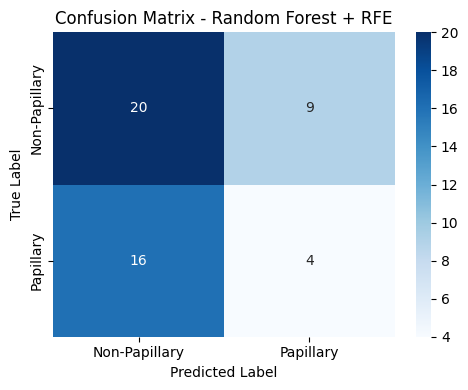

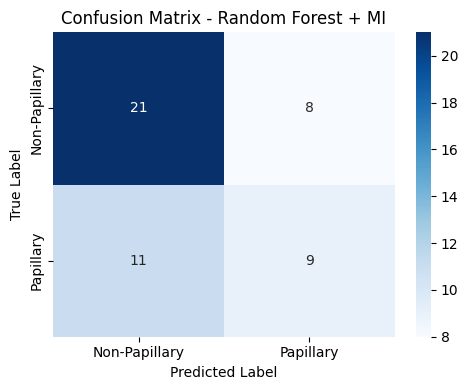

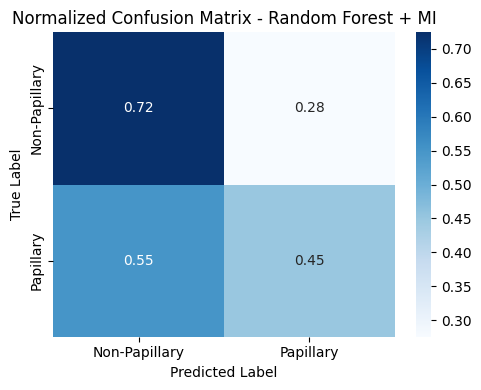

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf_anova = np.array([[24, 5],
                        [15, 5]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_anova, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - Random Forest + ANOVA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

cm_rf_rfe = np.array([[20, 9],
                      [16, 4]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_rfe, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - Random Forest + RFE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

cm_rf_mi = np.array([[21, 8],
                     [11, 9]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_mi, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - Random Forest + MI")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_mi / cm_rf_mi.sum(axis=1, keepdims=True),
            annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Normalized Confusion Matrix - Random Forest + MI")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

LOGISTIC REGRESSION

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# =====================================
# 1. LOAD LABEL (PAPILLARY = 1)
# =====================================

df_label = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_label.csv")
df_label.columns = df_label.columns.str.strip()

# SOLUSI 2: Papillary jadi kelas positif (1)
df_label["label"] = df_label["subtype"].apply(
    lambda x: 1 if x == "papillary" else 0
)

print("\nDistribusi Kelas:")
print(df_label["label"].value_counts())

# =====================================
# 2. CV STRATEGY (NESTED)
# =====================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# =====================================
# 3. HYPERPARAMETER SPACE
# =====================================

param_dist = {
    "clf__C": np.logspace(-3, 3, 20),
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs", "liblinear"],
    "clf__class_weight": ["balanced", None]
}

# =====================================
# 4. NESTED FUNCTION (MACRO F1)
# =====================================

def evaluate_lr_binary(csv_path, model_name):

    print("\n====================================")
    print("MODEL:", model_name)
    print("====================================")

    df = pd.read_csv(csv_path)

    df = df.merge(
        df_label[["case_id", "label"]],
        on="case_id",
        how="inner"
    )

    X = df.drop(columns=["case_id", "label"])
    y = df["label"]

    print("Jumlah fitur :", X.shape[1])
    print("Jumlah sampel:", X.shape[0])

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    fold_idx = 1

    for train_idx, test_idx in outer_cv.split(X, y):

        print(f"\n--- Outer Fold {fold_idx} ---")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                random_state=42
            ))
        ])

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_dist,
            n_iter=30,
            scoring="f1_macro",   # SOLUSI 1
            n_jobs=-1,
            cv=inner_cv,
            random_state=42,
            verbose=0
        )

        search.fit(X_train, y_train)

        best_model = search.best_estimator_

        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(y_proba)

        print("Best Inner CV Macro-F1:", search.best_score_)

        fold_idx += 1

    y_proba_all = np.array(y_proba_all)

    # =====================================
    # FINAL METRICS
    # =====================================

    acc = accuracy_score(y_true_all, y_pred_all)
    prec = precision_score(y_true_all, y_pred_all)
    rec = recall_score(y_true_all, y_pred_all)
    f1_val = f1_score(y_true_all, y_pred_all)
    cm = confusion_matrix(y_true_all, y_pred_all)

    auc = roc_auc_score(y_true_all, y_proba_all)

    print("\n===== FINAL NESTED CV RESULT =====")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1-score :", round(f1_val,4))
    print("AUC :", round(auc,4))
    print("Confusion Matrix:\n", cm)

    return acc, prec, rec, f1_val, auc, cm


# =====================================
# 5. RUN
# =====================================

lr_anova = evaluate_lr_binary(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERANOVA.csv",
    "Logistic Regression + ANOVA (Binary, Papillary=1)"
)

lr_rfe = evaluate_lr_binary(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERRFE_LSVM.csv",
    "Logistic Regression + RFE (Binary, Papillary=1)"
)

lr_mi = evaluate_lr_binary(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERMI.csv",
    "Logistic Regression + MI (Binary, Papillary=1)"
)


Distribusi Kelas:
label
0    29
1    20
Name: count, dtype: int64

MODEL: Logistic Regression + ANOVA (Binary, Papillary=1)
Jumlah fitur : 20
Jumlah sampel: 49

--- Outer Fold 1 ---
Best Inner CV Macro-F1: 0.6333964646464647

--- Outer Fold 2 ---
Best Inner CV Macro-F1: 0.6433358308358308

--- Outer Fold 3 ---
Best Inner CV Macro-F1: 0.7103625541125541

--- Outer Fold 4 ---
Best Inner CV Macro-F1: 0.788961038961039

--- Outer Fold 5 ---
Best Inner CV Macro-F1: 0.6895833333333332

===== FINAL NESTED CV RESULT =====
Accuracy : 0.5918
Precision: 0.5
Recall   : 0.65
F1-score : 0.5652
AUC : 0.5828
Confusion Matrix:
 [[16 13]
 [ 7 13]]

MODEL: Logistic Regression + RFE (Binary, Papillary=1)
Jumlah fitur : 20
Jumlah sampel: 49

--- Outer Fold 1 ---
Best Inner CV Macro-F1: 0.7863095238095238

--- Outer Fold 2 ---
Best Inner CV Macro-F1: 0.7422077922077922

--- Outer Fold 3 ---
Best Inner CV Macro-F1: 0.799006549006549

--- Outer Fold 4 ---
Best Inner CV Macro-F1: 0.8102453102453102

--- Outer

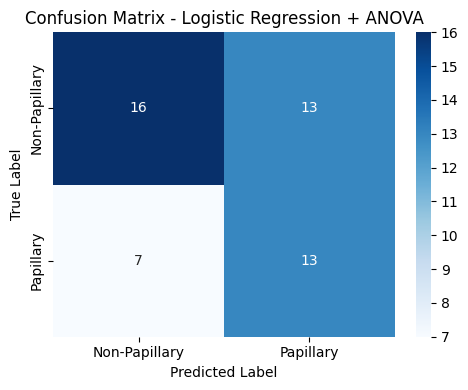

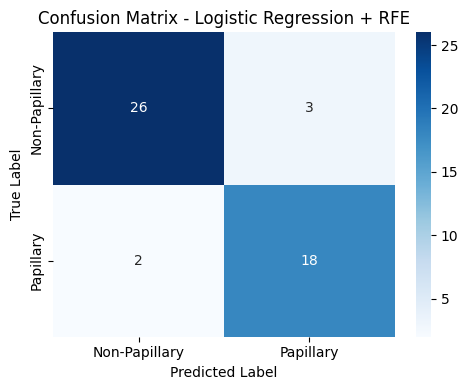

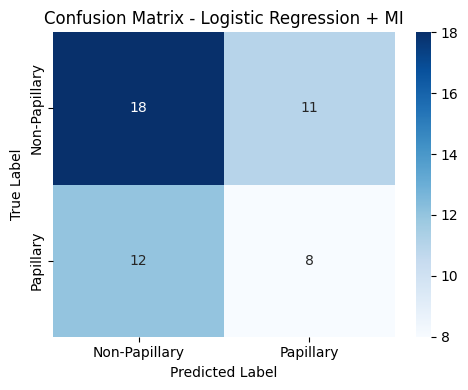

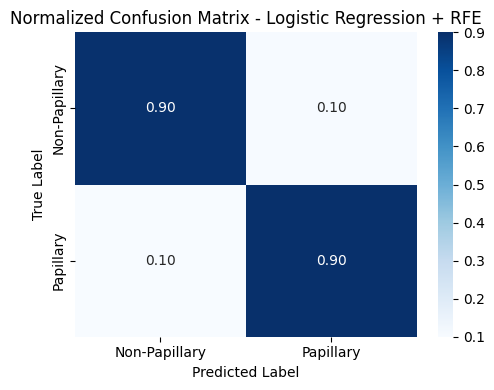

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_lr_anova = np.array([[16, 13],
                        [ 7, 13]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr_anova, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - Logistic Regression + ANOVA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

cm_lr_rfe = np.array([[26, 3],
                      [ 2,18]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr_rfe, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - Logistic Regression + RFE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

cm_lr_mi = np.array([[18,11],
                     [12, 8]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr_mi, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - Logistic Regression + MI")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr_rfe / cm_lr_rfe.sum(axis=1, keepdims=True),
            annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Normalized Confusion Matrix - Logistic Regression + RFE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

STACKING RF LR

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# ============================================================
# LOAD LABEL
# ============================================================

df_label = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_label.csv")
df_label.columns = df_label.columns.str.strip()

df_label["label"] = df_label["subtype"].apply(
    lambda x: 1 if x == "papillary" else 0
)

print("\nDistribusi Kelas:")
print(df_label["label"].value_counts())

# ============================================================
# NESTED CV
# ============================================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# ============================================================
# PARAMETER SPACE
# ============================================================

param_dist = {
    "stack__rf__n_estimators": [30, 50, 70],
    "stack__rf__max_depth": [2, 3, 4],
    "stack__rf__min_samples_leaf": [2, 3, 4],

    "stack__lr__C": np.logspace(-2, 2, 8),
    "stack__final_estimator__C": np.logspace(-2, 2, 8),
}

# ============================================================
# FUNCTION
# ============================================================

def evaluate_stacking(csv_path, model_name):

    print("\n====================================")
    print("MODEL:", model_name)
    print("====================================")

    df = pd.read_csv(csv_path)

    df = df.merge(
        df_label[["case_id", "label"]],
        on="case_id",
        how="inner"
    )

    X = df.drop(columns=["case_id", "label"])
    y = df["label"]

    print("Jumlah fitur :", X.shape[1])
    print("Jumlah sampel:", X.shape[0])

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    fold_idx = 1

    for train_idx, test_idx in outer_cv.split(X, y):

        print(f"\n--- Outer Fold {fold_idx} ---")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        rf = RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        )

        lr = LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        )

        stack = StackingClassifier(
            estimators=[
                ("rf", rf),
                ("lr", lr)
            ],
            final_estimator=LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42
            ),
            stack_method="predict_proba",
            passthrough=False,
            n_jobs=-1
        )

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("stack", stack)
        ])

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_dist,
            n_iter=25,
            scoring="f1_macro",
            cv=inner_cv,
            n_jobs=-1,
            random_state=42,
            verbose=0
        )

        search.fit(X_train, y_train)

        best_model = search.best_estimator_

        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(y_proba)

        print("Best Inner CV Macro-F1:", round(search.best_score_,4))

        fold_idx += 1

    y_proba_all = np.array(y_proba_all)

    # ============================================================
    # FINAL METRICS
    # ============================================================

    acc = accuracy_score(y_true_all, y_pred_all)
    prec = precision_score(y_true_all, y_pred_all, zero_division=0)
    rec = recall_score(y_true_all, y_pred_all, zero_division=0)
    f1_binary = f1_score(y_true_all, y_pred_all, zero_division=0)
    f1_macro = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)
    auc = roc_auc_score(y_true_all, y_proba_all)
    cm = confusion_matrix(y_true_all, y_pred_all)

    print("\n===== FINAL NESTED CV RESULT =====")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 (Binary) :", round(f1_binary,4))
    print("F1 (Macro)  :", round(f1_macro,4))
    print("AUC :", round(auc,4))
    print("Confusion Matrix:\n", cm)

    return acc, prec, rec, f1_binary, f1_macro, auc, cm


# ============================================================
# RUN (PAKAI STABLE FILE)
# ============================================================

stack_anova = evaluate_stacking(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERANOVA.csv",
    "Stacking RF+LR + ANOVA"
)

stack_rfe = evaluate_stacking(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERRFE_LSVM.csv",
    "Stacking RF+LR + RFE"
)

stack_mi = evaluate_stacking(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERMI.csv",
    "Stacking RF+LR + MI"
)


Distribusi Kelas:
label
0    29
1    20
Name: count, dtype: int64

MODEL: Stacking RF+LR + ANOVA
Jumlah fitur : 20
Jumlah sampel: 49

--- Outer Fold 1 ---
Best Inner CV Macro-F1: 0.636

--- Outer Fold 2 ---
Best Inner CV Macro-F1: 0.5634

--- Outer Fold 3 ---
Best Inner CV Macro-F1: 0.6833

--- Outer Fold 4 ---
Best Inner CV Macro-F1: 0.683

--- Outer Fold 5 ---
Best Inner CV Macro-F1: 0.4853

===== FINAL NESTED CV RESULT =====
Accuracy : 0.4694
Precision: 0.35
Recall   : 0.35
F1 (Binary) : 0.35
F1 (Macro)  : 0.4509
AUC : 0.4397
Confusion Matrix:
 [[16 13]
 [13  7]]

MODEL: Stacking RF+LR + RFE
Jumlah fitur : 20
Jumlah sampel: 49

--- Outer Fold 1 ---
Best Inner CV Macro-F1: 0.7863

--- Outer Fold 2 ---
Best Inner CV Macro-F1: 0.7441

--- Outer Fold 3 ---
Best Inner CV Macro-F1: 0.799

--- Outer Fold 4 ---
Best Inner CV Macro-F1: 0.808

--- Outer Fold 5 ---
Best Inner CV Macro-F1: 0.7408

===== FINAL NESTED CV RESULT =====
Accuracy : 0.8571
Precision: 0.8095
Recall   : 0.85
F1 (Binary

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# ============================================================
# LOAD LABEL
# ============================================================

df_label = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_label.csv")
df_label.columns = df_label.columns.str.strip()

df_label["label"] = df_label["subtype"].apply(
    lambda x: 1 if x == "papillary" else 0
)

print("\nDistribusi Kelas:")
print(df_label["label"].value_counts())

# ============================================================
# NESTED CV
# ============================================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# ============================================================
# PARAMETER SPACE
# ============================================================

param_dist = {

    "stack__rf__n_estimators": [30, 50, 70],
    "stack__rf__max_depth": [2, 3, 4],
    "stack__rf__min_samples_leaf": [2, 3, 4],

    "stack__lr__C": np.logspace(-2, 2, 8),

    "stack__final_estimator__C": np.logspace(-2, 2, 8)
}

# ============================================================
# FUNCTION
# ============================================================

def evaluate_stacking(csv_path, model_name):

    print("\n====================================")
    print("MODEL:", model_name)
    print("====================================")

    df = pd.read_csv(csv_path)

    df = df.merge(
        df_label[["case_id", "label"]],
        on="case_id",
        how="inner"
    )

    X = df.drop(columns=["case_id", "label"])
    y = df["label"]

    print("Jumlah fitur :", X.shape[1])
    print("Jumlah sampel:", X.shape[0])

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    best_params_all = []

    fold_idx = 1

    for train_idx, test_idx in outer_cv.split(X, y):

        print(f"\n========== OUTER FOLD {fold_idx} ==========")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # BASE MODELS
        rf = RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        )

        lr = LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        )

        # STACKING MODEL
        stack = StackingClassifier(
            estimators=[
                ("rf", rf),
                ("lr", lr)
            ],
            final_estimator=LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42
            ),
            stack_method="predict_proba",
            passthrough=False,
            n_jobs=-1
        )

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("stack", stack)
        ])

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_dist,
            n_iter=25,
            scoring="f1_macro",
            cv=inner_cv,
            n_jobs=-1,
            random_state=42
        )

        search.fit(X_train, y_train)

        print("\nBest Parameters:")
        print(search.best_params_)

        best_params_all.append(search.best_params_)

        best_model = search.best_estimator_

        stack_model = best_model.named_steps["stack"]

        print("\n--- Final Model Configuration ---")

        print("\nRandom Forest Parameters:")
        print(stack_model.named_estimators_["rf"].get_params())

        print("\nLogistic Regression (Base) Parameters:")
        print(stack_model.named_estimators_["lr"].get_params())

        print("\nMeta Learner Parameters:")
        print(stack_model.final_estimator_.get_params())

        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(y_proba)

        print("\nBest Inner CV Macro-F1:", round(search.best_score_,4))

        fold_idx += 1

    y_proba_all = np.array(y_proba_all)

    # ============================================================
    # FINAL METRICS
    # ============================================================

    acc = accuracy_score(y_true_all, y_pred_all)
    prec = precision_score(y_true_all, y_pred_all, zero_division=0)
    rec = recall_score(y_true_all, y_pred_all, zero_division=0)

    f1_binary = f1_score(y_true_all, y_pred_all, zero_division=0)
    f1_macro = f1_score(y_true_all, y_pred_all, average="macro")

    auc = roc_auc_score(y_true_all, y_proba_all)

    cm = confusion_matrix(y_true_all, y_pred_all)

    print("\n===== FINAL NESTED CV RESULT =====")

    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1 (Binary) :", round(f1_binary,4))
    print("F1 (Macro)  :", round(f1_macro,4))
    print("AUC :", round(auc,4))

    print("Confusion Matrix:\n", cm)

    return acc, prec, rec, f1_binary, f1_macro, auc, cm, best_params_all


# ============================================================
# RUN
# ============================================================

stack_anova = evaluate_stacking(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERANOVA.csv",
    "Stacking RF + LR (ANOVA)"
)

stack_rfe = evaluate_stacking(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERRFE_LSVM.csv",
    "Stacking RF + LR (RFE)"
)

stack_mi = evaluate_stacking(
    "/content/drive/MyDrive/kits19/radiomics_FULLHIGHORDERMI.csv",
    "Stacking RF + LR (MI)"
)


Distribusi Kelas:
label
0    29
1    20
Name: count, dtype: int64

MODEL: Stacking RF + LR (ANOVA)
Jumlah fitur : 20
Jumlah sampel: 49

========== OUTER FOLD 1 ==========

Best Parameters:
{'stack__rf__n_estimators': 70, 'stack__rf__min_samples_leaf': 4, 'stack__rf__max_depth': 3, 'stack__lr__C': np.float64(0.0372759372031494), 'stack__final_estimator__C': np.float64(26.826957952797247)}

--- Final Model Configuration ---

Random Forest Parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 70, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Logistic Regression (Base) Parameters:
{'C': np.float64(0.0372759372031494), 'class_weight': 'balanced', 'dual': False, 'fit_inte

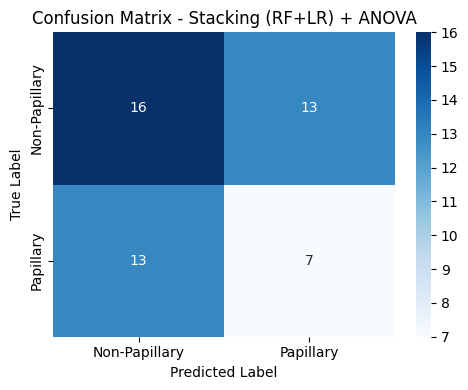

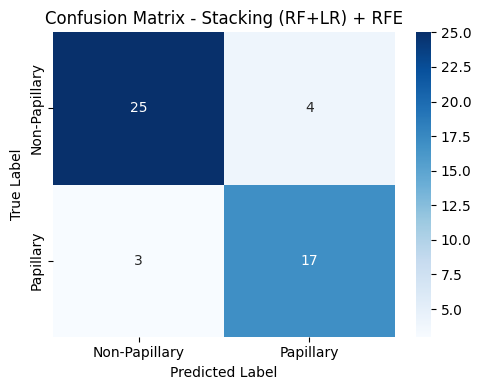

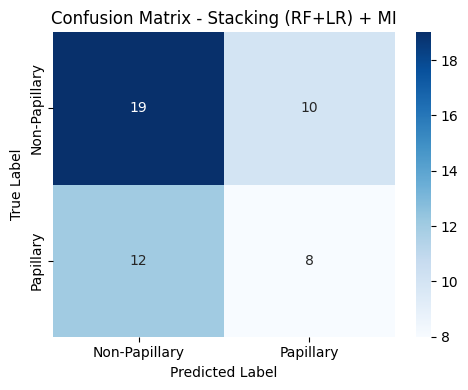

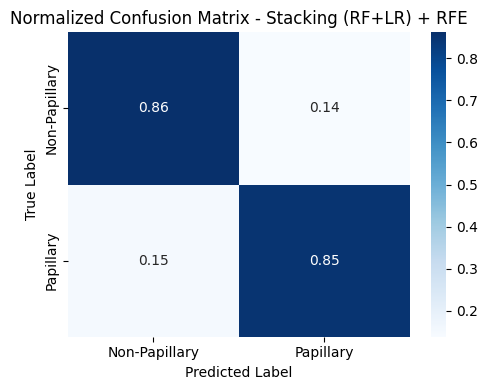

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


cm_stack_anova = np.array([[16,13],
                           [13, 7]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_stack_anova, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - Stacking (RF+LR) + ANOVA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

cm_stack_rfe = np.array([[25, 4],
                         [ 3,17]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_stack_rfe, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - Stacking (RF+LR) + RFE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
cm_stack_mi = np.array([[19,10],
                        [12, 8]])

plt.figure(figsize=(5,4))
sns.heatmap(cm_stack_mi, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Confusion Matrix - Stacking (RF+LR) + MI")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
plt.figure(figsize=(5,4))
sns.heatmap(cm_stack_rfe / cm_stack_rfe.sum(axis=1, keepdims=True),
            annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Non-Papillary", "Papillary"],
            yticklabels=["Non-Papillary", "Papillary"])
plt.title("Normalized Confusion Matrix - Stacking (RF+LR) + RFE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

JOBLIB

In [ ]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression


# ============================================================
# 1. LOAD LABEL
# ============================================================

df_label = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_label.csv")
df_label.columns = df_label.columns.str.strip()

# Papillary = 1, lainnya = 0
df_label["label"] = df_label["subtype"].apply(
    lambda x: 1 if x == "papillary" else 0
)

print("Distribusi kelas:")
print(df_label["label"].value_counts())


# ============================================================
# 2. LOAD DATA FITUR MI (Top 20)
# ============================================================

csv_path = "/content/drive/MyDrive/kits19/radiomics50_HIGHORDER_WaveletSqrt_FS97_MI_k20.csv"

df = pd.read_csv(csv_path)

# Merge fitur dengan label
df = df.merge(
    df_label[["case_id", "label"]],
    on="case_id",
    how="inner"
)

print("Jumlah sampel setelah merge:", df.shape[0])

X = df.drop(columns=["case_id", "label"])
y = df["label"]

print("Jumlah fitur:", X.shape[1])


# ============================================================
# 3. DEFINE PIPELINE
# ============================================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])


# ============================================================
# 4. HYPERPARAMETER SEARCH
# ============================================================

param_dist = {
    "clf__C": np.logspace(-3, 3, 20),
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs", "liblinear"],
    "clf__class_weight": ["balanced", None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    n_jobs=-1,
    cv=cv,
    random_state=42,
    verbose=1
)

search.fit(X, y)

print("\nBest Parameters:")
print(search.best_params_)
print("Best CV F1-Macro:", search.best_score_)


# ============================================================
# 5. FIT FINAL MODEL KE SELURUH DATA
# ============================================================

final_model = search.best_estimator_
final_model.fit(X, y)


# ============================================================
# 6. SIMPAN MODEL DAN FEATURE LIST
# ============================================================

joblib.dump(final_model, "lr_final_mi_binary.joblib")

selected_features = X.columns.tolist()
joblib.dump(selected_features, "mi_selected_features.joblib")

print("\nModel Logistic Regression + MI berhasil disimpan.")


# ============================================================
# 7. SIMPAN DATASET FINAL KE CSV
# ============================================================

# Dataset clean: case_id + fitur MI + label
df_final = pd.concat([df[["case_id"]], X, y], axis=1)

output_csv_path = "dataset_final_lr_mi_binary.csv"
df_final.to_csv(output_csv_path, index=False)

print("\nDataset final berhasil disimpan.")
print("Lokasi file:", output_csv_path)
print("Shape dataset final:", df_final.shape)

Distribusi kelas:
label
0    29
1    20
Name: count, dtype: int64
Jumlah sampel setelah merge: 49
Jumlah fitur: 20
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'clf__solver': 'lbfgs', 'clf__penalty': 'l2', 'clf__class_weight': 'balanced', 'clf__C': np.float64(0.1623776739188721)}
Best CV F1-Macro: 0.5531657231657232

Model Logistic Regression + MI berhasil disimpan.

Dataset final berhasil disimpan.
Lokasi file: dataset_final_lr_mi_binary.csv
Shape dataset final: (49, 22)


In [ ]:
# ============================================================
# IMPORT
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression


# ============================================================
# LOAD LABEL
# ============================================================

df_label = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_label.csv")
df_label.columns = df_label.columns.str.strip()

df_label["label"] = df_label["subtype"].apply(
    lambda x: 1 if x == "papillary" else 0
)


# ============================================================
# LOAD DATA RFE (TERBAIK)
# ============================================================

csv_path = "/content/drive/MyDrive/kits19/radiomics50_HIGHORDER_WaveletSqrt_FS97_RFE_LSVM_k20.csv"

df = pd.read_csv(csv_path)

df = df.merge(
    df_label[["case_id", "label"]],
    on="case_id",
    how="inner"
)

X = df.drop(columns=["case_id", "label"])
y = df["label"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah sampel:", X.shape[0])


# ============================================================
# PIPELINE
# ============================================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])


# ============================================================
# HYPERPARAMETER SEARCH
# ============================================================

param_dist = {
    "clf__C": np.logspace(-3, 3, 20),
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs", "liblinear"],
    "clf__class_weight": ["balanced", None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    n_jobs=-1,
    cv=cv,
    random_state=42,
    verbose=1
)

search.fit(X, y)

print("\nBest Parameters:", search.best_params_)
print("Best CV Score:", search.best_score_)


# ============================================================
# FIT FINAL MODEL KE SELURUH DATA
# ============================================================

final_model = search.best_estimator_
final_model.fit(X, y)


# ============================================================
# SIMPAN KE GOOGLE DRIVE
# ============================================================

model_path = "/content/drive/MyDrive/kits19/lr_final_rfe_binary.joblib"
feature_path = "/content/drive/MyDrive/kits19/rfe_selected_features.joblib"

joblib.dump(final_model, model_path)
joblib.dump(X.columns.tolist(), feature_path)

print("\nJOBLIB BERHASIL DISIMPAN")
print("Model:", model_path)
print("Fitur:", feature_path)

Jumlah fitur: 20
Jumlah sampel: 49
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__class_weight': 'balanced', 'clf__C': np.float64(54.555947811685144)}
Best CV Score: 0.7988455988455989

JOBLIB BERHASIL DISIMPAN
Model: /content/drive/MyDrive/kits19/lr_final_rfe_binary.joblib
Fitur: /content/drive/MyDrive/kits19/rfe_selected_features.joblib


In [ ]:
# ============================================================
# IMPORT
# ============================================================

import pandas as pd
import joblib


# ============================================================
# PATH
# ============================================================

model_path = "/content/drive/MyDrive/kits19/lr_final_rfe_binary.joblib"
feature_path = "/content/drive/MyDrive/kits19/rfe_selected_features.joblib"

data_path = "/content/drive/MyDrive/kits19/radiomics50_HIGHORDER_WaveletSqrt_FS97_RFE_LSVM_k20.csv"


# ============================================================
# LOAD MODEL
# ============================================================

print("\n🔄 Memuat model `lr_final_rfe_binary.joblib`...")
model_for_inference = joblib.load(model_path)
features_for_prediction = joblib.load(feature_path)
print("✓ Model berhasil dimuat!")


# ============================================================
# LOAD DATA LAMA
# ============================================================

df_data = pd.read_csv(data_path)

print("\nShape data:", df_data.shape)


# ============================================================
# LOAD LABEL (untuk melihat perbandingan)
# ============================================================

df_label = pd.read_csv("/content/drive/MyDrive/kits19/radiomics_label.csv")
df_label.columns = df_label.columns.str.strip()

df_label["label"] = df_label["subtype"].apply(
    lambda x: 1 if x == "papillary" else 0
)

df_data = df_data.merge(
    df_label[["case_id", "label"]],
    on="case_id",
    how="inner"
)


# ============================================================
# PREPARE FITUR
# ============================================================

X_data = df_data[features_for_prediction]


# ============================================================
# PREDIKSI
# ============================================================

print("\n🔄 Melakukan prediksi pada dataset training...")

predictions = model_for_inference.predict(X_data)
probabilities = model_for_inference.predict_proba(X_data)[:, 1]

df_data["Predicted_Label"] = predictions
df_data["Probability_Papillary"] = probabilities

print("✓ Prediksi selesai!")


# ============================================================
# TAMPILKAN HASIL
# ============================================================

print("\n=======================================================")
print("✅ Hasil Prediksi (Training Data)")
print("=======================================================")

display(
    df_data[
        ["case_id", "label", "Predicted_Label", "Probability_Papillary"]
    ].head()
)

print("\nDistribusi prediksi:")
print(df_data["Predicted_Label"].value_counts())


# ============================================================
# SIMPAN HASIL
# ============================================================

output_path = "/content/drive/MyDrive/kits19/hasil_prediksi_training_lr_rfe.csv"

df_data[[
    "case_id",
    "label",
    "Predicted_Label",
    "Probability_Papillary"
]].to_csv(output_path, index=False)

print("\nFile hasil disimpan ke:")
print(output_path)


🔄 Memuat model `lr_final_rfe_binary.joblib`...
✓ Model berhasil dimuat!

Shape data: (49, 21)

🔄 Melakukan prediksi pada dataset training...
✓ Prediksi selesai!

✅ Hasil Prediksi (Training Data)


,case_id,label,Predicted_Label,Probability_Papillary
0,case_00001,1,1,0.998225
1,case_00002,1,1,0.985857
2,case_00021,1,1,0.975880
3,case_00039,1,1,0.999819
4,case_00044,1,1,0.971881



Distribusi prediksi:
Predicted_Label
0    29
1    20
Name: count, dtype: int64

File hasil disimpan ke:
/content/drive/MyDrive/kits19/hasil_prediksi_training_lr_rfe.csv


In [ ]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
import pandas as pd
import joblib

# ============================================================
# PATH
# ============================================================
base_path = "/content/drive/MyDrive/kits19/"

model_path = base_path + "lr_final_rfe_binary.joblib"
feature_path = base_path + "rfe_selected_features.joblib"
data_path = base_path + "radiomics50_HIGHORDER_WaveletSqrt_FS97_RFE_LSVM_k20.csv"

# ============================================================
# LOAD MODEL & FITUR
# ============================================================
print("🔄 Memuat model dan fitur...")

model = joblib.load(model_path)
selected_features = joblib.load(feature_path)

print("✓ Model berhasil dimuat!")
print("Jumlah fitur model:", len(selected_features))

# ============================================================
# LOAD DATASET
# ============================================================
df = pd.read_csv(data_path)

print("\nShape data:", df.shape)

# ============================================================
# CEK FITUR
# ============================================================
missing_features = [f for f in selected_features if f not in df.columns]

if len(missing_features) > 0:
    print("⚠️ Ada fitur yang tidak ditemukan:")
    print(missing_features)
else:
    print("✓ Semua fitur tersedia.")

X = df[selected_features]

# ============================================================
# PREDIKSI
# ============================================================
print("\n🔄 Melakukan prediksi...")

df["Predicted_Label"] = model.predict(X)
df["Probability_Class_1"] = model.predict_proba(X)[:, 1]

print("✓ Prediksi selesai!")

# ============================================================
# TAMPILKAN HASIL
# ============================================================

if "case_id" in df.columns:
    id_col = "case_id"
elif "PatientID" in df.columns:
    id_col = "PatientID"
else:
    id_col = None

print("\nMenampilkan prediksi dan confidence level:")

if id_col:
    display(df[[id_col, "Predicted_Label", "Probability_Class_1"]])
else:
    display(df[["Predicted_Label", "Probability_Class_1"]])

print("\nMenampilkan semua fitur beserta hasil prediksi:")
display(df)

# ============================================================
# SIMPAN HASIL
# ============================================================
output_path = base_path + "hasil_prediksi_full_lr_rfe.csv"
df.to_csv(output_path, index=False)

print("\nFile hasil disimpan ke:")
print(output_path)

🔄 Memuat model dan fitur...
✓ Model berhasil dimuat!
Jumlah fitur model: 20

Shape data: (49, 21)
✓ Semua fitur tersedia.

🔄 Melakukan prediksi...
✓ Prediksi selesai!

Menampilkan prediksi dan confidence level:


,case_id,Predicted_Label,Probability_Class_1
0,case_00001,1,9.982253e-01
1,case_00002,1,9.858572e-01
2,case_00021,1,9.758797e-01
3,case_00039,1,9.998192e-01
4,case_00044,1,9.718813e-01
5,case_00050,1,1.000000e+00
6,case_00064,1,9.715150e-01
7,case_00068,1,9.336051e-01
8,case_00094,1,9.994570e-01
9,case_00099,1,9.675917e-01



Menampilkan semua fitur beserta hasil prediksi:


,case_id,original_firstorder_Entropy,original_firstorder_Minimum,original_glrlm_LongRunHighGrayLevelEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_ZoneEntropy,log-sigma-1-0-mm-3D_glrlm_LongRunEmphasis,log-sigma-1-0-mm-3D_glszm_LargeAreaEmphasis,log-sigma-1-0-mm-3D_glszm_SizeZoneNonUniformityNormalized,log-sigma-2-0-mm-3D_glrlm_LongRunEmphasis,...,squareroot_glszm_GrayLevelNonUniformityNormalized,squareroot_glszm_LowGrayLevelZoneEmphasis,wavelet-LHL_firstorder_Maximum,wavelet-LHL_glrlm_LongRunLowGrayLevelEmphasis,wavelet-LHL_glrlm_RunEntropy,wavelet-LLL_glrlm_LongRunHighGrayLevelEmphasis,wavelet-LLL_glszm_LargeAreaHighGrayLevelEmphasis,wavelet-LLL_glszm_SizeZoneNonUniformity,Predicted_Label,Probability_Class_1
0,case_00001,1.411038,43.310623,143.895371,5.849917e+05,3.307352,5.607208,2.725642e+06,0.593699,18.304218,...,0.430845,0.486376,73.780543,0.573119,3.289442,125.469780,7.178654e+06,350.869001,1,9.982253e-01
1,case_00002,1.422382,95.720791,168.646263,1.192569e+06,3.567513,7.065548,7.002491e+06,0.485987,19.328490,...,0.292282,0.262399,68.469065,0.647253,3.366896,172.633532,1.183272e+07,287.970218,1,9.858572e-01
2,case_00021,1.299549,75.324380,87.959442,8.493533e+05,3.022462,8.487674,2.125536e+06,0.251082,17.528984,...,0.843341,0.237997,66.474528,0.421847,3.379848,172.391124,5.646430e+06,358.713846,1,9.758797e-01
3,case_00039,1.088302,66.396544,189.594788,1.590065e+06,4.390326,8.166853,3.988493e+06,0.254813,19.653428,...,0.811810,0.239331,54.017102,1.644054,3.268399,172.094400,8.925309e+06,214.428907,1,9.998192e-01
4,case_00044,1.544368,98.754837,200.155548,1.852041e+06,4.253418,10.142067,4.873826e+06,0.318790,24.148866,...,0.346342,0.202442,47.901584,0.956824,3.479325,314.041015,1.510749e+07,482.579404,1,9.718813e-01
5,case_00050,0.718733,58.649668,157.110286,1.351778e+06,4.041273,6.448486,1.165629e+07,0.392103,20.499890,...,0.751233,0.877607,34.395310,1.623988,3.110632,123.488296,2.007074e+07,106.426997,1,1.000000e+00
6,case_00064,1.059779,68.806572,132.088111,1.790334e+06,2.145466,8.835304,3.484711e+06,0.182800,20.852687,...,0.507812,0.671875,30.397880,2.138800,3.215969,108.356504,7.111968e+06,119.151042,1,9.715150e-01
7,case_00068,1.267242,33.364694,88.547219,7.214035e+05,3.874626,5.398325,1.991033e+06,0.565227,17.561059,...,0.340240,0.159316,63.205613,0.306860,3.170386,138.089572,6.951929e+06,341.536585,1,9.336051e-01
8,case_00094,0.625232,59.860630,288.924580,1.072486e+07,3.885717,8.678676,1.098285e+07,0.295114,21.211811,...,0.988484,0.995656,26.224557,7.214577,3.136855,109.301215,1.953253e+07,119.359504,1,9.994570e-01
9,case_00099,0.704547,69.124971,138.552067,6.318063e+06,2.801137,8.243052,1.096730e+07,0.218333,19.063730,...,0.762351,0.231860,34.950308,2.001436,3.101622,160.855136,2.229188e+07,76.078125,1,9.675917e-01



File hasil disimpan ke:
/content/drive/MyDrive/kits19/hasil_prediksi_full_lr_rfe.csv


In [ ]:
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=np.float64(54.555947811685144),
                                    class_weight='balanced', max_iter=5000,
                                    random_state=42, solver='liblinear'))])


In [ ]:
import pandas as pd
import numpy as np

# Ambil logistic regression dari pipeline
clf = model.named_steps["clf"]

# Ambil koefisien
coef = clf.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": coef,
    "Abs_Coefficient": np.abs(coef)
}).sort_values(by="Abs_Coefficient", ascending=False)

display(feature_importance)

,Feature,Coefficient,Abs_Coefficient
10,squareroot_glrlm_GrayLevelNonUniformity,5.110416,5.110416
19,wavelet-LLL_glszm_SizeZoneNonUniformity,-4.500045,4.500045
12,squareroot_glszm_GrayLevelNonUniformityNormalized,4.310471,4.310471
14,wavelet-LHL_firstorder_Maximum,-4.192705,4.192705
11,squareroot_glrlm_LowGrayLevelRunEmphasis,3.984425,3.984425
3,original_glszm_LargeAreaEmphasis,-3.822301,3.822301
18,wavelet-LLL_glszm_LargeAreaHighGrayLevelEmphasis,3.727031,3.727031
4,original_glszm_ZoneEntropy,3.709129,3.709129
5,log-sigma-1-0-mm-3D_glrlm_LongRunEmphasis,3.397163,3.397163
8,log-sigma-2-0-mm-3D_glrlm_LongRunEmphasis,-3.115062,3.115062


In [ ]:
import numpy as np

feature_importance["Odds_Ratio"] = np.exp(feature_importance["Coefficient"])
display(feature_importance)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
10,squareroot_glrlm_GrayLevelNonUniformity,5.110416,5.110416,165.739272
19,wavelet-LLL_glszm_SizeZoneNonUniformity,-4.500045,4.500045,0.011108
12,squareroot_glszm_GrayLevelNonUniformityNormalized,4.310471,4.310471,74.475566
14,wavelet-LHL_firstorder_Maximum,-4.192705,4.192705,0.015105
11,squareroot_glrlm_LowGrayLevelRunEmphasis,3.984425,3.984425,53.754393
3,original_glszm_LargeAreaEmphasis,-3.822301,3.822301,0.021877
18,wavelet-LLL_glszm_LargeAreaHighGrayLevelEmphasis,3.727031,3.727031,41.555566
4,original_glszm_ZoneEntropy,3.709129,3.709129,40.818235
5,log-sigma-1-0-mm-3D_glrlm_LongRunEmphasis,3.397163,3.397163,29.879199
8,log-sigma-2-0-mm-3D_glrlm_LongRunEmphasis,-3.115062,3.115062,0.044376


In [ ]:
import joblib

model_loaded = joblib.load("/content/drive/MyDrive/kits19/lr_final_rfe_binary.joblib")

print(model_loaded)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=np.float64(54.555947811685144),
                                    class_weight='balanced', max_iter=5000,
                                    random_state=42, solver='liblinear'))])


In [ ]:
import joblib

model_path = "/content/drive/MyDrive/kits19/lr_final_rfe_binary.joblib"

model = joblib.load(model_path)

print("Model berhasil dimuat!")
print(model)

Model berhasil dimuat!
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=np.float64(54.555947811685144),
                                    class_weight='balanced', max_iter=5000,
                                    random_state=42, solver='liblinear'))])


In [ ]:
clf = model.named_steps["clf"]

print("Koefisien:")
print(clf.coef_)

print("Intercept:")
print(clf.intercept_)

Koefisien:
[[ 2.95892325 -3.07881673 -2.69203086 -3.82230073  3.70912892  3.39716256
  -0.24605446  2.71283327 -3.11506189 -1.2191831   5.1104159   3.9844254
   4.3104711  -1.96689271 -4.19270491 -1.82505299  1.18830452  0.98456749
   3.72703148 -4.50004517]]
Intercept:
[-1.50212341]
